In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

In [3]:
df = pd.read_csv(
    "../dataset/processed/news_cleaned.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (209508, 8)


In [4]:
df.head()

,link,headline,category,short_description,authors,date,text,clean_text
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23,Over 4 Million Americans Roll Up Sleeves For O...,over 4 million americans roll up sleeves for o...
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23,"American Airlines Flyer Charged, Banned For Li...",american airlines flyer charged banned for lif...
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23,23 Of The Funniest Tweets About Cats And Dogs ...,23 of the funniest tweets about cats and dogs ...
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23,The Funniest Tweets From Parents This Week (Se...,the funniest tweets from parents this week sep...
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22,Woman Who Called Cops On Black Bird-Watcher Lo...,woman who called cops on black birdwatcher los...


In [5]:
df.columns.tolist()

['link',
 'headline',
 'category',
 'short_description',
 'authors',
 'date',
 'text',
 'clean_text']

#### Creating X and y variables

In [6]:
X = df["clean_text"]
y = df["category"]

In [7]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of categories:", y.nunique())

X shape: (209508,)
y shape: (209508,)

Number of categories: 42


In [8]:
print(y.value_counts().head())

category
POLITICS          35600
WELLNESS          17942
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9811
Name: count, dtype: int64


#### We will use stratification for splitting the data into train and test sets as there is imbalance in the target variable

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 167606
Testing samples: 41902


In [11]:
print("Training distribution:")
print(y_train.value_counts(normalize=True).head())

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True).head())

Training distribution:
category
POLITICS          0.169922
WELLNESS          0.085635
ENTERTAINMENT     0.082873
TRAVEL            0.047254
STYLE & BEAUTY    0.046830
Name: proportion, dtype: float64

Testing distribution:
category
POLITICS          0.169920
WELLNESS          0.085652
ENTERTAINMENT     0.082860
TRAVEL            0.047253
STYLE & BEAUTY    0.046824
Name: proportion, dtype: float64


#### Using TF-IDF to convert text into numerical features

In [12]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=50000
)

In [13]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [14]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (167606, 50000)
Testing TF-IDF shape: (41902, 50000)


In [15]:
print("Vocabulary size:", len(tfidf.vocabulary_))

Vocabulary size: 50000


In [16]:
print("First 20 features:")
print(tfidf.get_feature_names_out()[:20])

First 20 features:
['007' '10' '10 15' '10 20' '10 amazing' '10 americans' '10 beautiful'
 '10 best' '10 billion' '10 cities' '10 common' '10 companies'
 '10 countries' '10 days' '10 disgraceful' '10 easy' '10 essential'
 '10 extreme' '10 favorite' '10 feet']


In [17]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [18]:
y_pred = lr_model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


#### Calculating both weighted and macro model performance metrics

In [19]:
accuracy = accuracy_score(y_test, y_pred)

precision_weighted = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall_weighted = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1_weighted = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

precision_macro = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall_macro = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Accuracy:             {accuracy:.4f}")
print(f"Weighted Precision:   {precision_weighted:.4f}")
print(f"Weighted Recall:      {recall_weighted:.4f}")
print(f"Weighted F1:          {f1_weighted:.4f}")
print(f"Macro Precision:      {precision_macro:.4f}")
print(f"Macro Recall:         {recall_macro:.4f}")
print(f"Macro F1:             {f1_macro:.4f}")

Accuracy:             0.6045
Weighted Precision:   0.5983
Weighted Recall:      0.6045
Weighted F1:          0.5739
Macro Precision:      0.5833
Macro Recall:         0.4052
Macro F1:             0.4456


##### From the above results, it can be said that the model has learned useful category patterns but performance varies significantly across the 42 different categories of news articles present.

In [20]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
ARTS,0.377953,0.158940,0.223776,302.000000
ARTS & CULTURE,0.426667,0.119403,0.186589,268.000000
BLACK VOICES,0.573427,0.357688,0.440564,917.000000
BUSINESS,0.520909,0.478297,0.498695,1198.000000
COLLEGE,0.453988,0.323144,0.377551,229.000000
COMEDY,0.611511,0.393519,0.478873,1080.000000
CRIME,0.566423,0.544944,0.555476,712.000000
CULTURE & ARTS,0.789474,0.209302,0.330882,215.000000
DIVORCE,0.834572,0.655474,0.734260,685.000000
EDUCATION,0.495652,0.280788,0.358491,203.000000


In [21]:
category_performance = (
    report_df
    .iloc[:-3]
    .sort_values("f1-score", ascending=False)
)

category_performance[
    ["precision", "recall", "f1-score", "support"]
]

,precision,recall,f1-score,support
WEDDINGS,0.814480,0.738714,0.774749,731.0
STYLE & BEAUTY,0.729508,0.816514,0.770563,1962.0
POLITICS,0.650835,0.881461,0.748792,7120.0
DIVORCE,0.834572,0.655474,0.734260,685.0
TRAVEL,0.653862,0.799495,0.719382,1980.0
HOME & LIVING,0.739609,0.700231,0.719382,864.0
SPORTS,0.706931,0.703448,0.705185,1015.0
QUEER VOICES,0.794059,0.631994,0.703817,1269.0
FOOD & DRINK,0.610928,0.731861,0.665949,1268.0
ENTERTAINMENT,0.564493,0.800403,0.662061,3472.0


In [22]:
print("Top 10 categories:")
display(
    category_performance.head(10)
)

print("\nBottom 10 categories:")
display(
    category_performance.tail(10)
)

Top 10 categories:


,precision,recall,f1-score,support
WEDDINGS,0.814480,0.738714,0.774749,731.0
STYLE & BEAUTY,0.729508,0.816514,0.770563,1962.0
POLITICS,0.650835,0.881461,0.748792,7120.0
DIVORCE,0.834572,0.655474,0.734260,685.0
TRAVEL,0.653862,0.799495,0.719382,1980.0
HOME & LIVING,0.739609,0.700231,0.719382,864.0
SPORTS,0.706931,0.703448,0.705185,1015.0
QUEER VOICES,0.794059,0.631994,0.703817,1269.0
FOOD & DRINK,0.610928,0.731861,0.665949,1268.0
ENTERTAINMENT,0.564493,0.800403,0.662061,3472.0



Bottom 10 categories:


,precision,recall,f1-score,support
WORLDPOST,0.472973,0.203488,0.284553,516.0
HEALTHY LIVING,0.448630,0.195668,0.272491,1339.0
ENVIRONMENT,0.671233,0.169550,0.270718,289.0
STYLE,0.634783,0.161863,0.257951,451.0
FIFTY,0.722222,0.139286,0.233533,280.0
ARTS,0.377953,0.158940,0.223776,302.0
GOOD NEWS,0.478261,0.117857,0.189112,280.0
ARTS & CULTURE,0.426667,0.119403,0.186589,268.0
TASTE,0.494118,0.100239,0.166667,419.0
U.S. NEWS,0.400000,0.029091,0.054237,275.0


#### From the above output it can be seen that, category overlap is an issue and it is genuinely affecting the classifier.

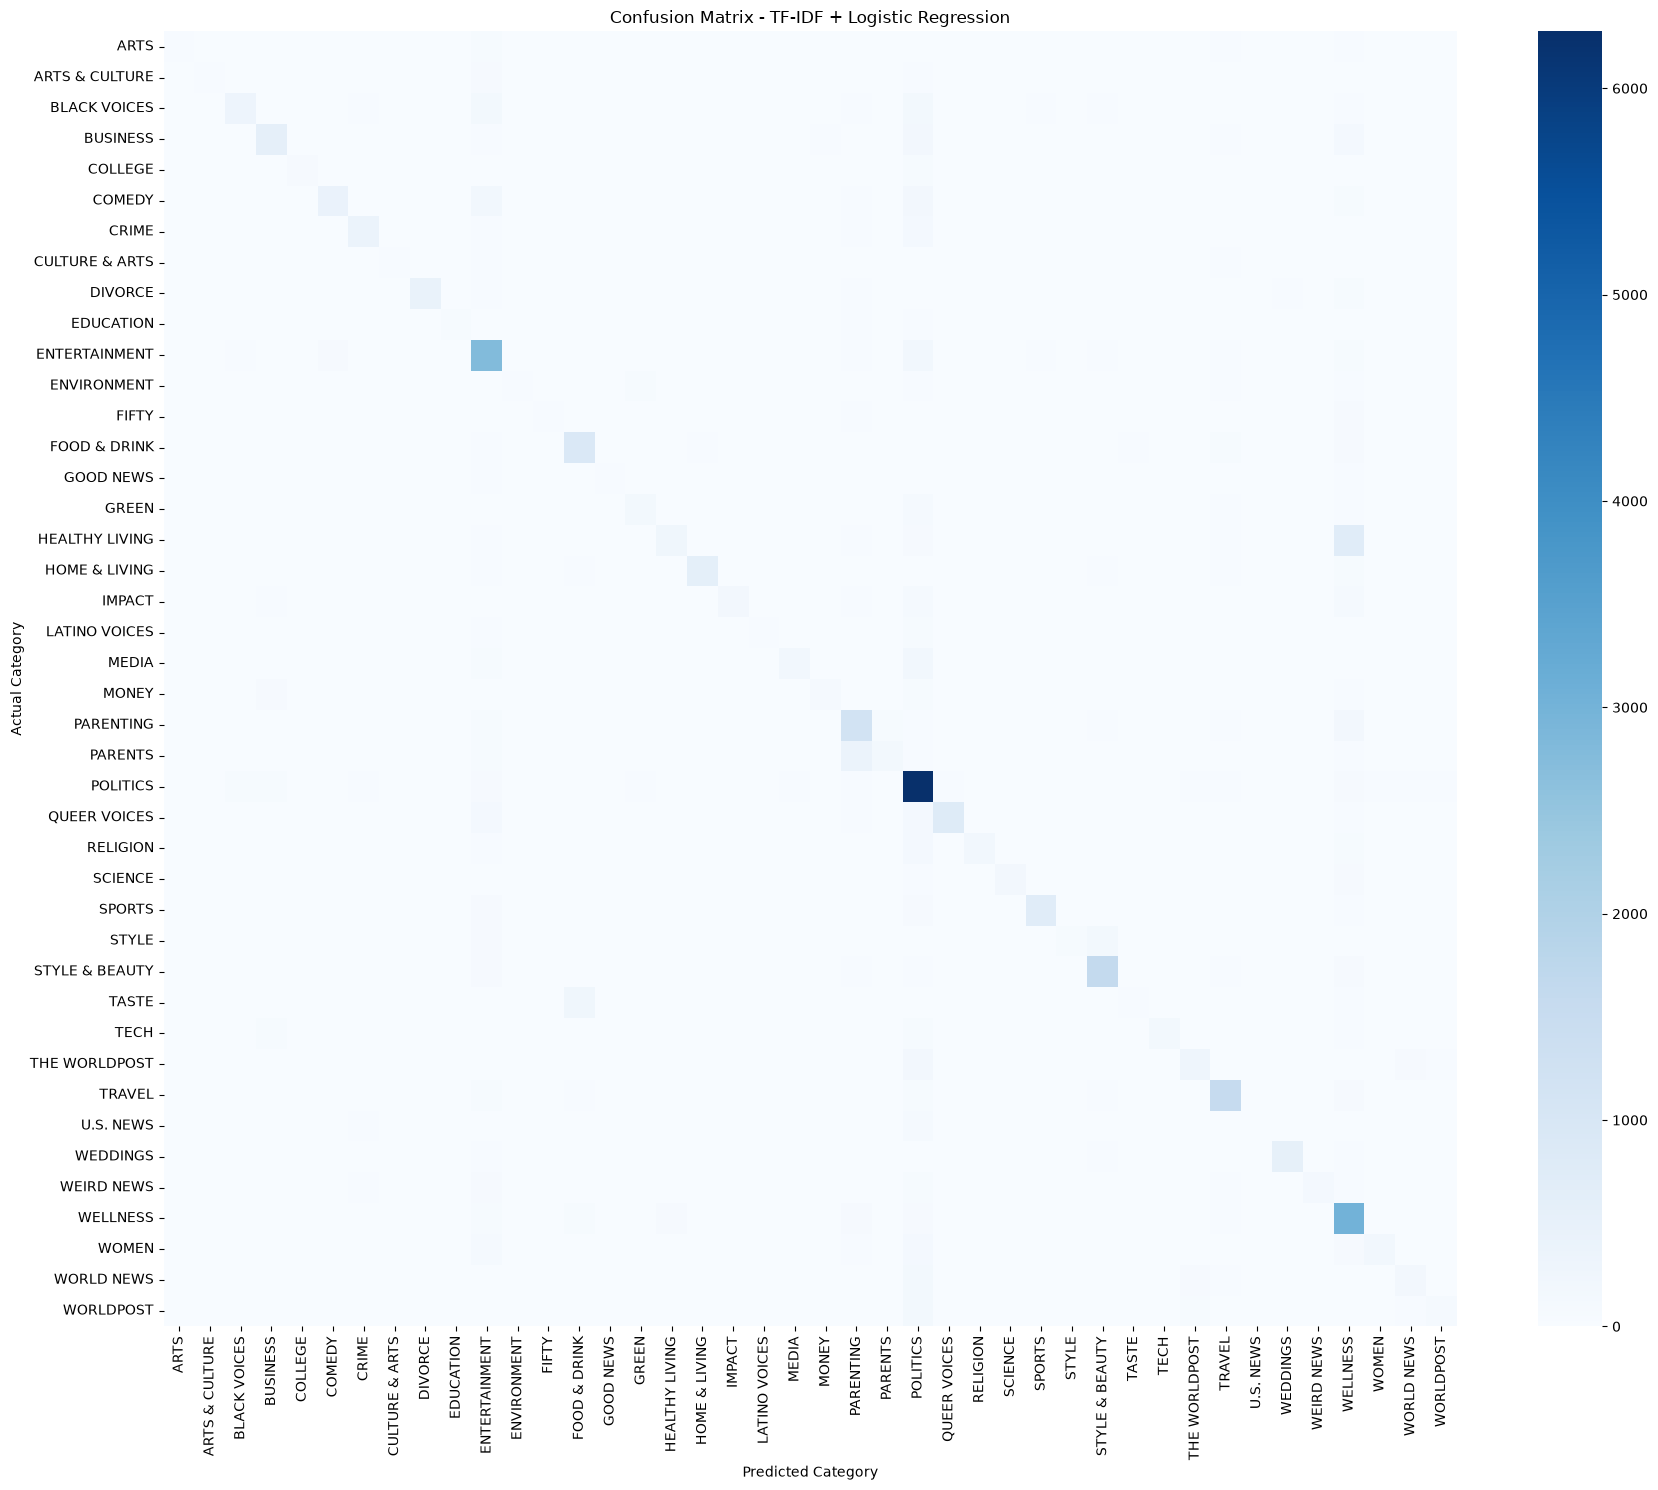

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)

plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [24]:
cm_df = pd.DataFrame(
    cm,
    index=lr_model.classes_,
    columns=lr_model.classes_
)

# Make a writable copy
cm_no_diag = cm_df.to_numpy().copy()

# Remove correct predictions from the diagonal
np.fill_diagonal(cm_no_diag, 0)

# Convert back to DataFrame
cm_df_no_diag = pd.DataFrame(
    cm_no_diag,
    index=lr_model.classes_,
    columns=lr_model.classes_
)

# Find the largest confusion pairs
confusion_pairs = (
    cm_df_no_diag
    .stack()
    .sort_values(ascending=False)
)

confusion_pairs.head(20)

HEALTHY LIVING  WELLNESS          716
PARENTS         PARENTING         383
TASTE           FOOD & DRINK      258
MEDIA           POLITICS          220
COMEDY          ENTERTAINMENT     216
ENTERTAINMENT   POLITICS          207
BUSINESS        POLITICS          196
PARENTING       WELLNESS          189
THE WORLDPOST   POLITICS          178
COMEDY          POLITICS          176
BLACK VOICES    ENTERTAINMENT     171
WORLD NEWS      POLITICS          169
BLACK VOICES    POLITICS          166
WORLDPOST       POLITICS          160
STYLE           STYLE & BEAUTY    159
CRIME           POLITICS          140
BUSINESS        WELLNESS          133
QUEER VOICES    ENTERTAINMENT     129
WOMEN           POLITICS          128
RELIGION        POLITICS          125
dtype: int64

In [25]:
baseline_metrics = {
    "Accuracy": accuracy,
    "Weighted Precision": precision_weighted,
    "Weighted Recall": recall_weighted,
    "Weighted F1": f1_weighted,
    "Macro Precision": precision_macro,
    "Macro Recall": recall_macro,
    "Macro F1": f1_macro
}

baseline_metrics

{'Accuracy': 0.6045057515154408,
 'Weighted Precision': 0.5983005318039598,
 'Weighted Recall': 0.6045057515154408,
 'Weighted F1': 0.5739167442266986,
 'Macro Precision': 0.5832905987084425,
 'Macro Recall': 0.4051570786399882,
 'Macro F1': 0.44557278855186105}

#### Logistic Regression with balanced weights

In [26]:
lr_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

lr_balanced.fit(X_train_tfidf, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [27]:
y_pred_balanced = lr_balanced.predict(X_test_tfidf)

In [28]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)

precision_weighted_balanced = precision_score(
    y_test,
    y_pred_balanced,
    average="weighted"
)

recall_weighted_balanced = recall_score(
    y_test,
    y_pred_balanced,
    average="weighted"
)

f1_weighted_balanced = f1_score(
    y_test,
    y_pred_balanced,
    average="weighted"
)

precision_macro_balanced = precision_score(
    y_test,
    y_pred_balanced,
    average="macro"
)

recall_macro_balanced = recall_score(
    y_test,
    y_pred_balanced,
    average="macro"
)

f1_macro_balanced = f1_score(
    y_test,
    y_pred_balanced,
    average="macro"
)

print(f"Accuracy:             {accuracy_balanced:.4f}")
print(f"Weighted Precision:   {precision_weighted_balanced:.4f}")
print(f"Weighted Recall:      {recall_weighted_balanced:.4f}")
print(f"Weighted F1:          {f1_weighted_balanced:.4f}")
print(f"Macro Precision:      {precision_macro_balanced:.4f}")
print(f"Macro Recall:         {recall_macro_balanced:.4f}")
print(f"Macro F1:             {f1_macro_balanced:.4f}")

Accuracy:             0.5547
Weighted Precision:   0.6160
Weighted Recall:      0.5547
Weighted F1:          0.5722
Macro Precision:      0.4531
Macro Recall:         0.5245
Macro F1:             0.4757


In [29]:
import torch
import transformers
import datasets
import accelerate

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Accelerate:", accelerate.__version__)

PyTorch: 2.11.0+cu128
Transformers: 5.17.0
Datasets: 5.0.1
Accelerate: 1.15.0


In [30]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("Using CPU")

CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA version: 12.8


## Transformer-Based Classification — DistilBERT

#### Prepare Labels

In [35]:
# Get the unique news categories
categories = sorted(y.unique())

print("Number of categories:", len(categories))
print(categories)

Number of categories: 42
['ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK', 'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT', 'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'PARENTS', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS', 'STYLE', 'STYLE & BEAUTY', 'TASTE', 'TECH', 'THE WORLDPOST', 'TRAVEL', 'U.S. NEWS', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS', 'WOMEN', 'WORLD NEWS', 'WORLDPOST']


In [36]:
label2id = {label: idx for idx, label in enumerate(categories)}
id2label = {idx: label for idx, label in enumerate(categories)}

print(label2id)

{'ARTS': 0, 'ARTS & CULTURE': 1, 'BLACK VOICES': 2, 'BUSINESS': 3, 'COLLEGE': 4, 'COMEDY': 5, 'CRIME': 6, 'CULTURE & ARTS': 7, 'DIVORCE': 8, 'EDUCATION': 9, 'ENTERTAINMENT': 10, 'ENVIRONMENT': 11, 'FIFTY': 12, 'FOOD & DRINK': 13, 'GOOD NEWS': 14, 'GREEN': 15, 'HEALTHY LIVING': 16, 'HOME & LIVING': 17, 'IMPACT': 18, 'LATINO VOICES': 19, 'MEDIA': 20, 'MONEY': 21, 'PARENTING': 22, 'PARENTS': 23, 'POLITICS': 24, 'QUEER VOICES': 25, 'RELIGION': 26, 'SCIENCE': 27, 'SPORTS': 28, 'STYLE': 29, 'STYLE & BEAUTY': 30, 'TASTE': 31, 'TECH': 32, 'THE WORLDPOST': 33, 'TRAVEL': 34, 'U.S. NEWS': 35, 'WEDDINGS': 36, 'WEIRD NEWS': 37, 'WELLNESS': 38, 'WOMEN': 39, 'WORLD NEWS': 40, 'WORLDPOST': 41}


In [37]:
y_train_encoded = y_train.map(label2id)
y_test_encoded = y_test.map(label2id)

print("Training labels:", y_train_encoded.shape)
print("Testing labels:", y_test_encoded.shape)
print("Unique training labels:", y_train_encoded.nunique())
print("Unique testing labels:", y_test_encoded.nunique())

Training labels: (167606,)
Testing labels: (41902,)
Unique training labels: 42
Unique testing labels: 42


#### Load DistilBERT Tokenizer

In [38]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [39]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

d:\Anaconda\envs\nlp\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Aniket\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [40]:
sample_text = X_train.iloc[0]

print(sample_text)

obama makes fun of those who somehow still think he is a muslim


In [41]:
encoded_sample = tokenizer(
    sample_text,
    truncation=True,
    padding="max_length",
    max_length=128
)

print(encoded_sample.keys())

KeysView({'input_ids': [101, 8112, 3084, 4569, 1997, 2216, 2040, 5064, 2145, 2228, 2002, 2003, 1037, 5152, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [42]:
print("Input IDs:", len(encoded_sample["input_ids"]))
print("Attention mask:", len(encoded_sample["attention_mask"]))

Input IDs: 128
Attention mask: 128


#### Creating Hugging Face datasets as Hugging Face's ecosystem is designed to work with dataset objects

In [43]:
from datasets import Dataset

In [44]:
train_df = pd.DataFrame({
    "text": X_train.reset_index(drop=True),
    "label": y_train_encoded.reset_index(drop=True)
})

test_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "label": y_test_encoded.reset_index(drop=True)
})

In [45]:
print("Training set:")
display(train_df.head())

print("\nTesting set:")
display(test_df.head())

Training set:


,text,label
0,obama makes fun of those who somehow still thi...,24
1,facebook just smashed six degrees of separatio...,32
2,six ways to bring out your loving self loving ...,36
3,turkey says rising antiamericanism can be calm...,33
4,deadly blasts hit funeral mourners after prote...,40



Testing set:


,text,label
0,escape from reality and care for yourself this...,18
1,facebook admits its probably not the best thin...,24
2,where in the world are people most depressed f...,38
3,rightwing media’s antifa obsession is creating...,24
4,rose mcgowan flashes blue lacy bra under revea...,30


In [46]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [47]:
print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 167606
})
Dataset({
    features: ['text', 'label'],
    num_rows: 41902
})


In [48]:
from datasets import DatasetDict

dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 167606
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 41902
    })
})


In [49]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [51]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/167606 [00:00<?, ? examples/s]

Map:   0%|          | 0/41902 [00:00<?, ? examples/s]

In [52]:
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 167606
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 41902
    })
})


In [ ]:
# Inspecting a tokenized example from the training dataset
sample = tokenized_dataset["train"][0]

print("Text:")
print(sample["text"])

print("\nLabel:")
print(sample["label"])

print("\nInput IDs:")
print(sample["input_ids"][:20])

print("\nAttention Mask:")
print(sample["attention_mask"][:20])

Text:
obama makes fun of those who somehow still think he is a muslim

Label:
24

Input IDs:
[101, 8112, 3084, 4569, 1997, 2216, 2040, 5064, 2145, 2228, 2002, 2003, 1037, 5152, 102, 0, 0, 0, 0, 0]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


In [54]:
print("\nInput ID length:", len(sample["input_ids"]))
print("Attention mask length:", len(sample["attention_mask"]))


Input ID length: 128
Attention mask length: 128


#### Verifying if max_length = 128 is sufficient for the dataset

In [55]:
sample_train = train_df["text"].sample(
    n=5000,
    random_state=42
)

In [56]:
token_lengths = [
    len(tokenizer.encode(text, add_special_tokens=True))
    for text in sample_train
]

In [57]:
import numpy as np

print("Average token length:", np.mean(token_lengths))
print("Median token length:", np.median(token_lengths))
print("Maximum token length:", np.max(token_lengths))

print(
    "Texts exceeding 128 tokens:",
    sum(length > 128 for length in token_lengths)
)

print(
    "Percentage exceeding 128 tokens:",
    (sum(length > 128 for length in token_lengths) / len(token_lengths)) * 100
)

Average token length: 34.832
Median token length: 34.0
Maximum token length: 269
Texts exceeding 128 tokens: 7
Percentage exceeding 128 tokens: 0.13999999999999999


##### Only 7 articles out of the randomly sampled 5000 exceed 128 tokens. Hence, we can proceed with this.

In [58]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(categories),
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [60]:
print("Number of labels:", model.config.num_labels)
print("Model:", model_name)
print("Hidden size:", model.config.dim)

Number of labels: 42
Model: distilbert-base-uncased
Hidden size: 768


In [63]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [64]:
model.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [65]:
print(next(model.parameters()).device)

cuda:0


In [66]:
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

In [67]:
tokenized_dataset.set_format("torch")

#### DistilBERT model training

In [68]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [69]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "weighted_precision": precision,
        "weighted_recall": recall,
        "weighted_f1": f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1
    }

In [70]:
from transformers import TrainingArguments, Trainer

In [71]:
training_args = TrainingArguments(
    output_dir="./models/distilbert-news",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    fp16=True,
    report_to="none"
)

In [72]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics
)

In [74]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
1,1.097624,1.093796,0.678297,0.669656,0.678297,0.667730,0.607190,0.542358,0.562351
2,0.902536,1.030238,0.699179,0.692303,0.699179,0.691601,0.621199,0.581349,0.593596
3,0.718397,1.056094,0.698749,0.691986,0.698749,0.693719,0.614589,0.587252,0.598144


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [75]:
# Predictions on test set
test_predictions = trainer.predict(
    tokenized_dataset["test"]
)

In [76]:
y_pred_distilbert = np.argmax(
    test_predictions.predictions,
    axis=-1
)

In [80]:
# Calculate DistilBERT metrics

accuracy_distilbert = accuracy_score(
    y_test_encoded,
    y_pred_distilbert
)

precision_distilbert, recall_distilbert, f1_distilbert, _ = (
    precision_recall_fscore_support(
        y_test_encoded,
        y_pred_distilbert,
        average="weighted",
        zero_division=0
    )
)

macro_precision_distilbert, macro_recall_distilbert, macro_f1_distilbert, _ = (
    precision_recall_fscore_support(
        y_test_encoded,
        y_pred_distilbert,
        average="macro",
        zero_division=0
    )
)

print(f"Accuracy:             {accuracy_distilbert:.4f}")
print(f"Weighted Precision:   {precision_distilbert:.4f}")
print(f"Weighted Recall:      {recall_distilbert:.4f}")
print(f"Weighted F1:          {f1_distilbert:.4f}")
print(f"Macro Precision:      {macro_precision_distilbert:.4f}")
print(f"Macro Recall:         {macro_recall_distilbert:.4f}")
print(f"Macro F1:             {macro_f1_distilbert:.4f}")

Accuracy:             0.6987
Weighted Precision:   0.6920
Weighted Recall:      0.6987
Weighted F1:          0.6937
Macro Precision:      0.6146
Macro Recall:         0.5873
Macro F1:             0.5981


In [81]:
distilbert_report = classification_report(
    y_test_encoded,
    y_pred_distilbert,
    target_names=categories,
    zero_division=0
)

print(distilbert_report)

                precision    recall  f1-score   support

          ARTS       0.52      0.45      0.48       302
ARTS & CULTURE       0.49      0.44      0.46       268
  BLACK VOICES       0.56      0.54      0.55       917
      BUSINESS       0.58      0.59      0.58      1198
       COLLEGE       0.55      0.54      0.55       229
        COMEDY       0.60      0.55      0.57      1080
         CRIME       0.65      0.66      0.65       712
CULTURE & ARTS       0.54      0.45      0.49       215
       DIVORCE       0.83      0.80      0.82       685
     EDUCATION       0.49      0.48      0.48       203
 ENTERTAINMENT       0.74      0.78      0.76      3472
   ENVIRONMENT       0.61      0.45      0.52       289
         FIFTY       0.49      0.37      0.42       280
  FOOD & DRINK       0.74      0.79      0.77      1268
     GOOD NEWS       0.46      0.39      0.42       280
         GREEN       0.48      0.53      0.50       524
HEALTHY LIVING       0.56      0.47      0.51  

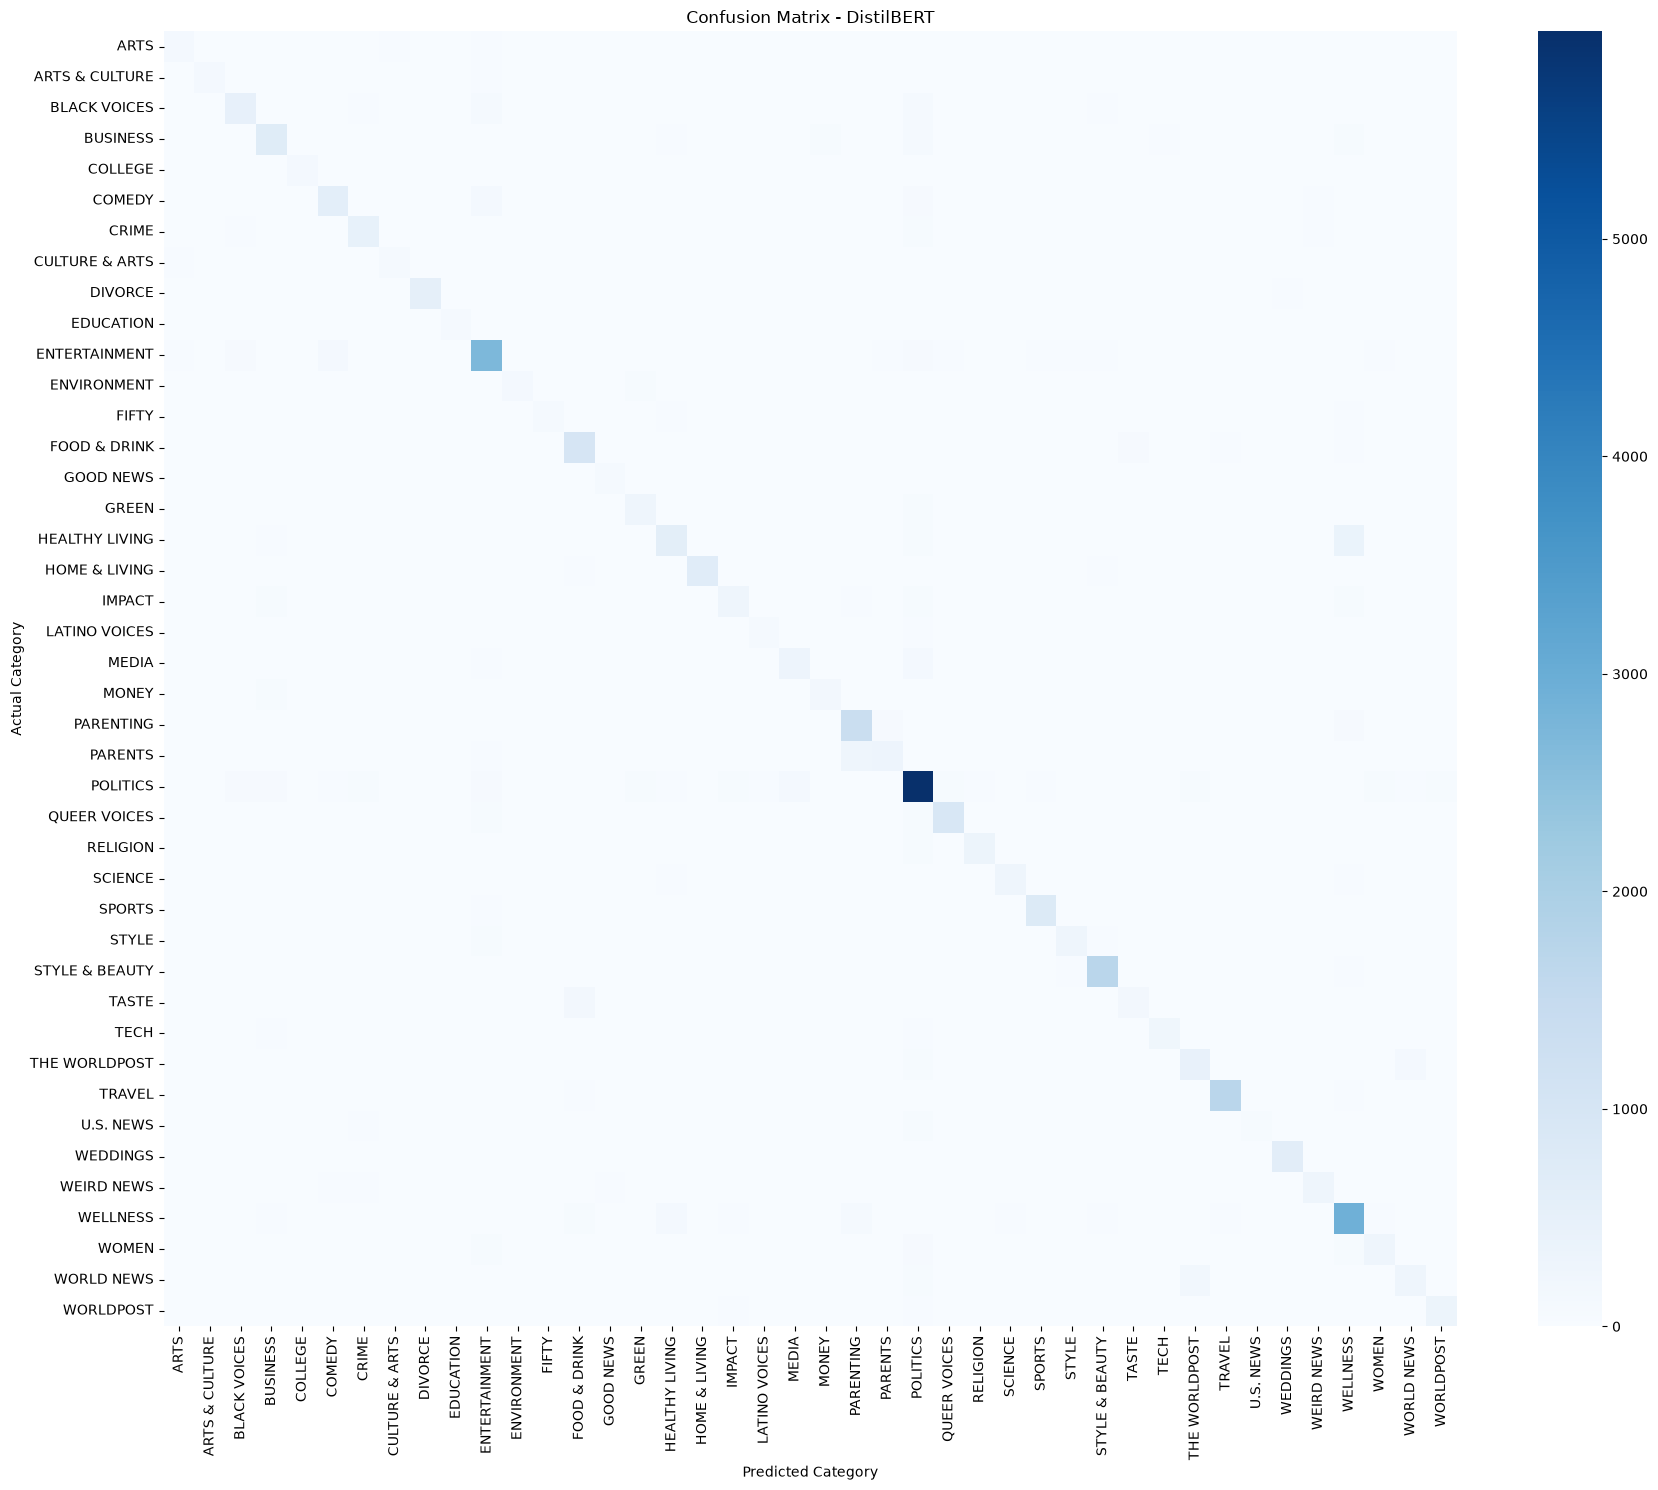

In [82]:
cm_distilbert = confusion_matrix(
    y_test_encoded,
    y_pred_distilbert
)

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm_distilbert,
    cmap="Blues",
    xticklabels=categories,
    yticklabels=categories
)

plt.title("Confusion Matrix - DistilBERT")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [83]:
cm_distilbert_df = pd.DataFrame(
    cm_distilbert,
    index=categories,
    columns=categories
)

cm_distilbert_no_diag = cm_distilbert.copy()

np.fill_diagonal(cm_distilbert_no_diag, 0)

cm_distilbert_no_diag_df = pd.DataFrame(
    cm_distilbert_no_diag,
    index=categories,
    columns=categories
)

distilbert_confusion_pairs = (
    cm_distilbert_no_diag_df
    .stack()
    .sort_values(ascending=False)
)

distilbert_confusion_pairs.head(20)

HEALTHY LIVING  WELLNESS          381
PARENTS         PARENTING         263
WORLD NEWS      THE WORLDPOST     202
TASTE           FOOD & DRINK      171
ENTERTAINMENT   COMEDY            136
COMEDY          ENTERTAINMENT     136
WELLNESS        HEALTHY LIVING    134
THE WORLDPOST   WORLD NEWS        132
MEDIA           POLITICS          120
POLITICS        MEDIA             118
BLACK VOICES    ENTERTAINMENT     105
BUSINESS        POLITICS           99
BLACK VOICES    POLITICS           97
WELLNESS        PARENTING          94
PARENTING       WELLNESS           93
ENTERTAINMENT   BLACK VOICES       93
FOOD & DRINK    TASTE              86
ENTERTAINMENT   POLITICS           83
POLITICS        BUSINESS           82
                BLACK VOICES       80
dtype: int64

#### DistilBERT provides a better classification performance as compared to the previous two modelling approaches. The classification accuracy is also fairly consistent across different categories in the case of DistilBERT

In [ ]:
# Comparing the three models
model_comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Balanced Logistic Regression",
        "DistilBERT"
    ],
    "Accuracy": [
        accuracy,
        accuracy_balanced,
        accuracy_distilbert
    ],
    "Weighted F1": [
        f1_weighted,
        f1_weighted_balanced,
        f1_distilbert
    ],
    "Macro F1": [
        f1_macro,
        f1_macro_balanced,
        macro_f1_distilbert
    ]
})

model_comparison.round(4)

,Model,Accuracy,Weighted F1,Macro F1
0,TF-IDF + Logistic Regression,0.6045,0.5739,0.4456
1,TF-IDF + Balanced Logistic Regression,0.5547,0.5722,0.4757
2,DistilBERT,0.6987,0.6937,0.5981


In [85]:
# Saving the DistilBERT model and tokenizer
model_save_path = "../models/distilbert-news"

trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"Model and tokenizer saved to: {model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: ../models/distilbert-news


In [86]:
import os

for root, dirs, files in os.walk("../models/distilbert-news"):
    for file in files:
        filepath = os.path.join(root, file)
        print(filepath)

../models/distilbert-news\config.json
../models/distilbert-news\model.safetensors
../models/distilbert-news\tokenizer.json
../models/distilbert-news\tokenizer_config.json
../models/distilbert-news\training_args.bin
